# Parametric Structural Optimization

In this notebook, we explore the minimization of compliance of a parametric structure made of a linear elastic material. The structure is parametrized by N bars, each of which has M segments. We seek the ideal configuration of the Y coordinates of the vertices that connect those bar segments. This notebook is based on the 2D topology optimization from the `jax-fem` library as seen [here](https://github.com/deepmodeling/jax-fem/tree/main/demos/topology_optimization). 

Although topology optimization is a common approach to structural optimization, here we demonstrate the possibility of incorporating a design space into the optimization process. The design space is defined using a geometry library called PyVista, which does not support automatic differentiation. However, we can enable differentiability by using a finite difference approximation of the Jacobian matrix.

We denote the design space as a function $g$ that maps the design variables to a signed distance field. Then, we can then define the density field $\rho(\mathbf{x})$ as a function of the SDF value $g(\mathbf{x})$. Finally we denote the differentiable finite element method (FEM) solver as $f$, which takes the density field as input and returns the structure's compliance.  Therefore, the optimization problem can be formulated as follows:

\begin{equation}
\min_{\mathbf{y}} f(\rho(g(\mathbf{y}))).
\end{equation}

Here, $\mathbf{y}$ is the vector of design variables (the Y coordinates of the vertices).

## AD and Tesseracts

Since we want use a gradient based optimizer, we need to compute the gradient of the compliance with respect to the design variables. Hence we are interested in the following derivative:

\begin{equation}
\frac{\partial f}{\partial \mathbf{y}} = \frac{\partial f}{\partial \rho} \cdot \frac{\partial \rho}{\partial g} \cdot \frac{\partial g}{\partial \mathbf{y}}.
\end{equation}

Note that each term is a Jacobian matrix. With automatic differentiation libraries such as JAX, backpropagation uses the vector-Jacobian product to pull back the gradients over the entire pipeline.

Implementing the pipeline $f \circ \rho \circ g$ in a single project is difficult because we have to implement parts of the backpropagation ourselves. With the Tesseract library, however, we can wrap each function in a separate module and then compose them together. To enable differentiability, we can also define AD-relevant endpoints, such as the vector-Jacobian product, inside the tesseract module.

To understand more about building and running Tesseracts, please refer to the [Tesseract documentation](https://docs.pasteurlabs.ai/projects/tesseract-core/latest/).

## Setup

Lets install the required packages and build the two tesseract modules. Building the tesseracts can take a few minutes as they are docker containers.

In [15]:
# Install additional requirements for this notebook
%pip install -r requirements.txt -q

/anaconda/envs/scipy/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


In [16]:
import tesseract_core

tesseract_core.build_tesseract("design_tess", None)
tesseract_core.build_tesseract("fem_tess", None)

Image(id='sha256:1151cb90e5187be5888a3b253a095a50023a820d7c8740d0530e221bbc68c5cd', short_id='sha256:1151cb90e518', tags=['jax-fem-structure:jax-fem-structure', 'jax-fem-structure:latest'], attrs={'Id': 'sha256:1151cb90e5187be5888a3b253a095a50023a820d7c8740d0530e221bbc68c5cd', 'RepoTags': ['jax-fem-structure:jax-fem-structure', 'jax-fem-structure:latest'], 'RepoDigests': [], 'Parent': '', 'Comment': 'buildkit.dockerfile.v0', 'Created': '2025-06-13T13:20:22.141626646Z', 'Container': '', 'ContainerConfig': {'Hostname': '', 'Domainname': '', 'User': '', 'AttachStdin': False, 'AttachStdout': False, 'AttachStderr': False, 'Tty': False, 'OpenStdin': False, 'StdinOnce': False, 'Env': None, 'Cmd': None, 'Image': '', 'Volumes': None, 'WorkingDir': '', 'Entrypoint': None, 'OnBuild': None, 'Labels': None}, 'DockerVersion': '', 'Author': '', 'Config': {'Hostname': '', 'Domainname': '', 'User': 'tesseractor', 'AttachStdin': False, 'AttachStdout': False, 'AttachStderr': False, 'ExposedPorts': {'8000

## Design Space Tesseract

First, let's import the tesseract_core library and serve the design space tesseract, which is equivalent to the function $g$ in the equation above.

In [17]:
import jax.numpy as jnp
from tesseract_core import Tesseract

In [18]:
design = Tesseract.from_image("design")
design.serve()

Let's setup the parameters for the design space and apply the design tesseract. The tesseract internally constructs a 3D geometry using PyVista and computes the signed distance field (SDF).

In [19]:
n_chains = 4
n_edges_per_chain = 5
bar_radius = 0.7
bar_overlap = 0.35

Lx = 60
Ly = 30
Nx = 120
Ny = 60

# Initialize chain parameter array
params = jnp.zeros((n_chains, n_edges_per_chain + 1, 3), dtype=jnp.float32)

for chain in range(n_chains):
    params = params.at[chain, :, 0].set(
        jnp.linspace(
            -Lx/2, 
            Lx/2, 
            n_edges_per_chain + 1))

    # add an offset
    params = params.at[chain, :, 1].set(chain / n_chains * 5.0 - 2.5)

sdf = design.apply(
    {
        "bar_params": params,
        "bar_radius": bar_radius,
        "bar_overlap": bar_overlap,
        "Lx": Lx,
        "Ly": Ly,
        "Nx": Nx,
        "Ny": Ny,
        "epsilon": 1e-3, # epsilon, only used for FD of the jacobian
    }
)["sdf"]

print("SDF shape:", sdf.shape)

SDF shape: (120, 60)


Now import some plotting functions and visualize the structure and its SDF field.

/anaconda/envs/scipy/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


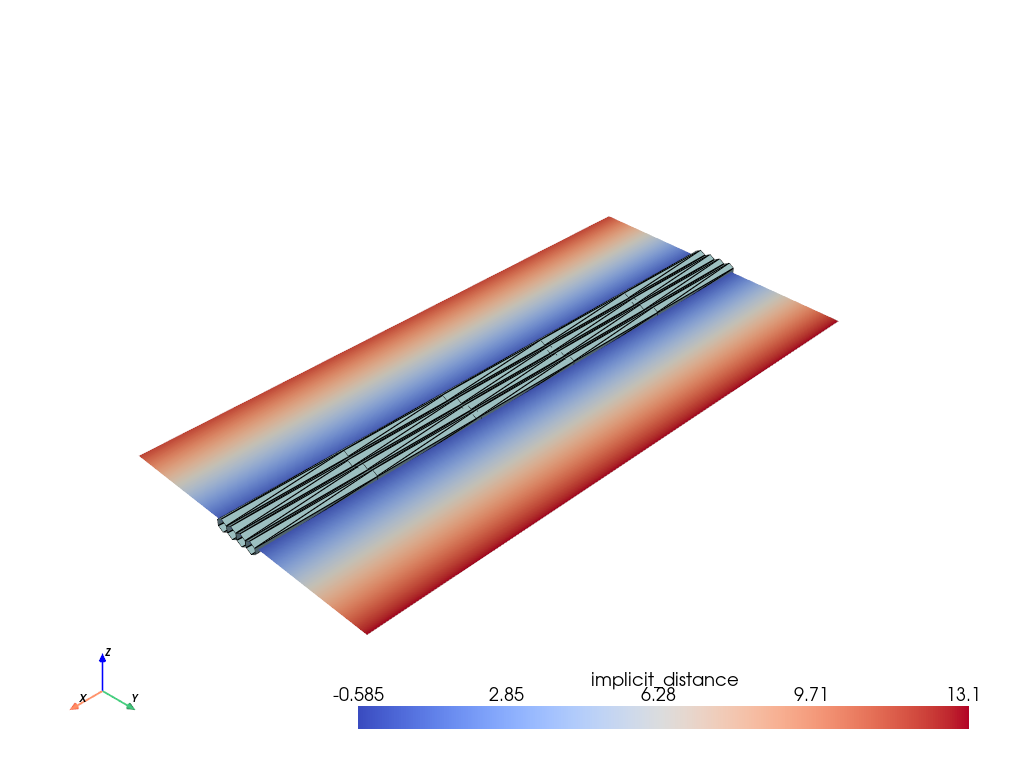

In [20]:
from design_tess.tesseract_api import build_geometry, sdf_plane
import pyvista as pv

def visualize(params):
    """Visualize the geometry defined by the parameters."""
    geometry = build_geometry(
        params,
        radius=bar_radius,
        overlap=bar_overlap)

    plane = sdf_plane(
        params, 
        radius=bar_radius,
        overlap=bar_overlap,
        Lx=Lx,
        Ly=Ly,
        Nx=Nx,
        Ny=Ny)

    plotter = pv.Plotter()
    plotter.add_mesh(geometry, color='lightblue', show_edges=True, edge_color='black')
    plotter.add_axes()
    plotter.add_mesh(plane, scalars="implicit_distance", cmap='coolwarm', show_edges=False)
    plotter.show()

visualize(params)

Instead of calling the apply endpoint we can also call the vector-Jacobian product endpoint which is used for backpropagation. This endpoint computes the Jacobian of the SDF with respect to the design variables, which is useful for gradient-based optimization. Hence we define the ``vjp_inputs`` as ``bar_params`` and the ``vjp_outputs`` as ``sdf``. 

In [21]:
grad = design.vector_jacobian_product(
    inputs = {
        "bar_params": params,
        "bar_radius": bar_radius,
        "bar_overlap": bar_overlap,
        "Lx": Lx,
        "Ly": Ly,
        "Nx": Nx,
        "Ny": Ny,
        "epsilon": 1e-3, # epsilon, only used for FD of the jacobian
    },
    vjp_inputs = ["bar_params"],
    vjp_outputs = ["sdf"],
    cotangent_vector = {
        "sdf": jnp.ones((Nx, Ny), dtype=jnp.float32)
    }
)["bar_params"]

print("Gradient shape:", grad.shape)

Gradient shape: (4, 6, 3)


Instead of manually supplying all the relevant information regarding the vjp inputs, ouputs and the cotangent vector we can use the tesseract-jax library. Tesseract-jax automatically registers the AD endpoints from the tesseract as lowering primitives in JAX. We can see this in action by using the ``jax.jvp`` function.

In [22]:
from tesseract_jax import apply_tesseract
import jax

primal, vjp_fun = jax.vjp(
    lambda params : apply_tesseract(
        design,
        {
            "bar_params": params,
            "bar_radius": bar_radius,
            "bar_overlap": bar_overlap,
            "Lx": Lx,
            "Ly": Ly,
            "Nx": Nx,
            "Ny": Ny,
            "epsilon": 0.01,  # Smoothing parameter for SDF computation
        }
    )["sdf"],
    params
)

grad = vjp_fun(jnp.ones((Nx, Ny), dtype=jnp.float32))[0]

print("Gradient shape:", grad.shape)


Gradient shape: (4, 6, 3)


## SDF to Density Field

Now that we have the signed distance field (SDF) from the design space, we can proceed to compute the density field, that is we need to define the function $\rho$ that maps the SDF to a density value. This function needs to be smooth and differentiable to ensure that the optimization process can effectively navigate the design space. We use a parametrized sigmoid function, which ensures that the density values are bounded between 0 and 1. Here $s$ is the slope of the sigmoid and $o$ is the offset. The parameters $s$ and $o$ can be adjusted to control the steepness and position of the transition between 0 and 1 in the density field.

\begin{equation}
    \rho(\text{SDF}) = \frac{1}{1 + e^{s \cdot \text{SDF} - o}}
\end{equation}

Since this function is straight forward to implement, we can directly use the JAX library to define it.

In [23]:
def sdf_to_rho(
   sdf: jnp.ndarray, 
   scale: float = 4.0, 
   offset: float = 1.0
) -> jnp.ndarray:
   """
   Convert signed distance function to material density using sigmoid.
   
   Args:
       sdf: Signed distance function values.
       scale: Sigmoid steepness (higher = sharper transition).
       offset: SDF value where density = 0.5.
       
   Returns:
       Material density field in [0,1].
   """
   return 1 / (1 + jnp.exp(scale * sdf - offset))

To verify the conversion, we can visualize the density field:

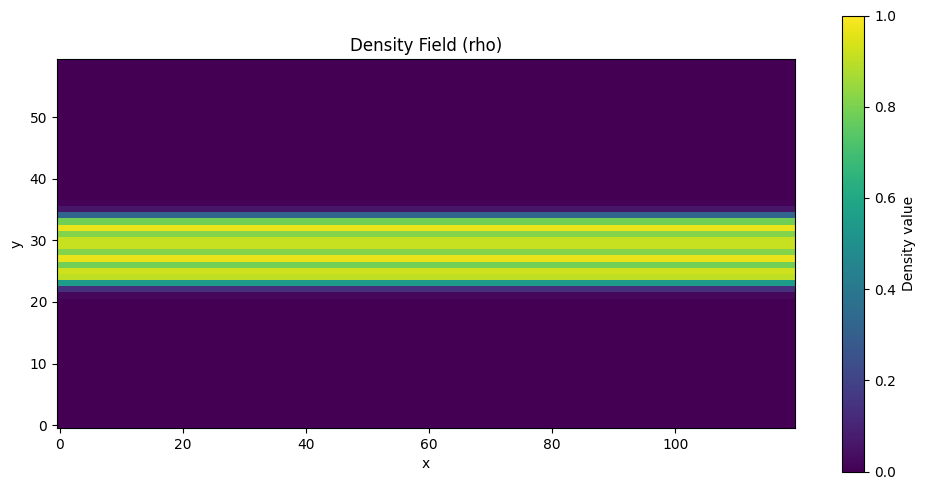

In [24]:
import matplotlib.pyplot as plt

rho = sdf_to_rho(sdf)
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(
    rho.T,
    origin="lower",
    cmap="viridis",
    vmin=0,
    vmax=1
)
ax.set_title("Density Field (rho)")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="Density value")
plt.tight_layout()

## FEM Tesseract

Now that we have a density field, we compute the compliance the structure. The compliance tesseract is using the jax-fem finite library internally. Jax-FEM is a fully differentiable finite element library. Inside the tesseract the boundary conditions are already hard coded, where the entire left side is a dirichlet boundary condition and bottom right side is a neumann boundary condition. 

In [25]:
fem = Tesseract.from_image("jax-fem-structure")
fem.serve()

We use tesseract in combination tesseract-jax to compute the compliance of the structure.

In [26]:
compliance = apply_tesseract(
    fem,
    {
        "rho": jnp.reshape(rho, (Nx * Ny, 1)),
        "Lx": Lx,
        "Ly": Ly,
        "Nx": Nx,
        "Ny": Ny,
    }
)["compliance"]
print(f"Compliance: {compliance:.4f}")

Compliance: 14564.3838


## Parametric Topology Optimization

Now that we have all the components of the pipeline, we can compose them together and define the loss function for the optimization. The loss function is simply the compliance of the structure, which we can compute by applying the FEM tesseract to the density field obtained from the design space tesseract.

In [27]:
import optax

def loss(params: jnp.ndarray) -> float:
   """
   Compute structural compliance for given bar parameters.
   
   Args:
       params: Bar parameter array with shape (n_chains, n_nodes, 3).
       
   Returns:
       Structural compliance (scalar). Lower values indicate better performance.
   """
   # Generate signed distance field from design parameters
   sdf = apply_tesseract(
       design,
       {
           "bar_params": params,
           "bar_radius": bar_radius,
           "bar_overlap": bar_overlap,
           "Lx": Lx,
           "Ly": Ly,
           "Nx": Nx,
           "Ny": Ny,
           "epsilon": 0.01,  # epsilon for finite difference
       }
   )["sdf"]
   
   # Convert SDF to material density distribution
   rho = sdf_to_rho(sdf)
   
   # Compute structural compliance via finite element analysis
   compliance = apply_tesseract(
       fem,
       {
           "rho": jnp.reshape(rho, (Nx * Ny, 1)),  # Flatten for FEM solver
           "Lx": Lx,
           "Ly": Ly,
           "Nx": Nx,
           "Ny": Ny,
       }
   )["compliance"]
   
   return compliance

Now we can use JAX's `grad` function to compute the gradient of the compliance with respect to the design variables. Furthermore we use the Adam optimizer as defined in optax to perform the optimization. Note that for structural optimization, there are better optimizers available, such as MMA, but for simplicity we use Adam here. The optimization process will take a few minutes to run.

In [28]:
solver = optax.adam(learning_rate=0.4)
opt_state = solver.init(params)

los_hist = []
params_hist = []

for i in range(80):
    loss_value, grads = jax.value_and_grad(loss)(params)
    updates, opt_state = solver.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    
    los_hist.append(loss_value)
    params_hist.append(params)

    print(f"Iteration {i+1}, Loss: {loss_value:.4f}")

Iteration 1, Loss: 14564.3838
Iteration 2, Loss: 11865.4580
Iteration 3, Loss: 10175.6543
Iteration 4, Loss: 9206.3203
Iteration 5, Loss: 8504.4980
Iteration 6, Loss: 8100.1582
Iteration 7, Loss: 7671.0015
Iteration 8, Loss: 7511.6729
Iteration 9, Loss: 7304.8921
Iteration 10, Loss: 7051.6826
Iteration 11, Loss: 6865.5264
Iteration 12, Loss: 6603.3896
Iteration 13, Loss: 6329.5498
Iteration 14, Loss: 6074.7412
Iteration 15, Loss: 5841.1333
Iteration 16, Loss: 5597.4229
Iteration 17, Loss: 5349.0342
Iteration 18, Loss: 5111.1055
Iteration 19, Loss: 4866.8003
Iteration 20, Loss: 4569.6353
Iteration 21, Loss: 4243.5444
Iteration 22, Loss: 3833.1831
Iteration 23, Loss: 3338.1060
Iteration 24, Loss: 2823.3613
Iteration 25, Loss: 2412.7400
Iteration 26, Loss: 2091.6021
Iteration 27, Loss: 1857.7178
Iteration 28, Loss: 1696.0314
Iteration 29, Loss: 1603.3440
Iteration 30, Loss: 1537.8290
Iteration 31, Loss: 1487.1953
Iteration 32, Loss: 1421.2251
Iteration 33, Loss: 1362.4288
Iteration 34, Lo

Lets plot the compliance as a function of the optimization steps. We can see that the compliance is decreasing smoothly, indicating that the optimization is working as expected. 

Text(0.5, 1.0, 'Compliance over Optimization')

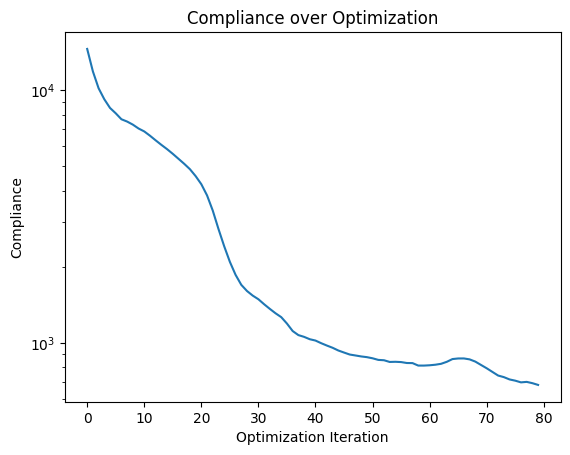

In [29]:
plt.plot(los_hist)
plt.yscale("log")
plt.xlabel("Optimization Iteration")
plt.ylabel("Compliance")
plt.title("Compliance over Optimization")

We can also trace the y coordinates of the vertices over the optimization steps. This gives us an idea of how the design variables are changing during the optimization process.

Text(0, 0.5, 'Y-Position')

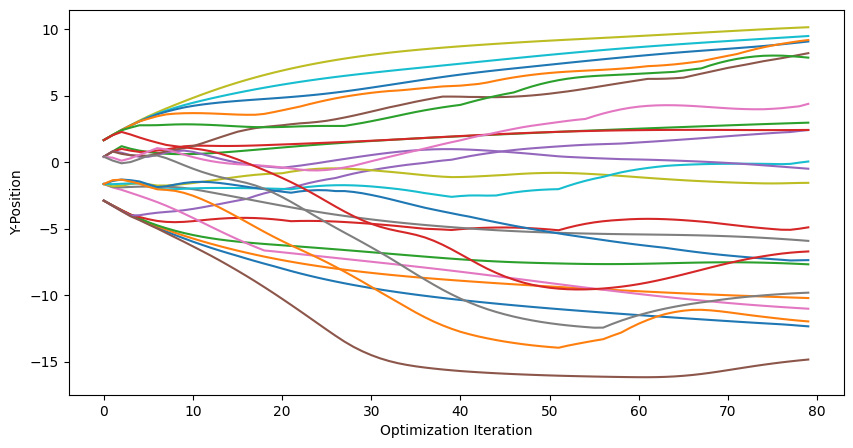

In [30]:
param_hist_tensor = jnp.array(params_hist)

plt.figure(figsize=(10, 5))

for chain in range(n_chains):
    for edge in range(n_edges_per_chain + 1):
        plt.plot(
            param_hist_tensor[:, chain, edge, 1].T,
            label=f"Chain {chain}, Edge {edge}"
        )

plt.xlabel("Optimization Iteration")
plt.ylabel("Y-Position")

We can also visualize the optimized structure and its SDF field.

/anaconda/envs/scipy/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


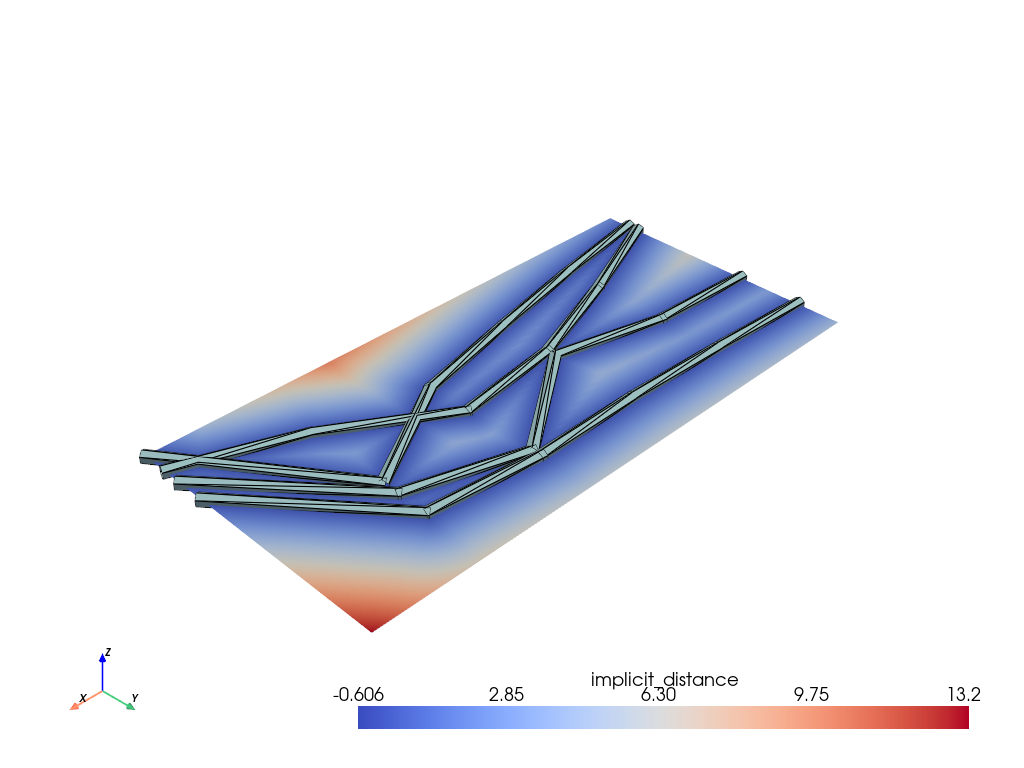

In [31]:
visualize(params)

And finally we generate a video of the optimization process to visualize how the structure evolves over time.

In [32]:
from matplotlib import animation

# repeat the last frame a few times to show the final result
params_hist = params_hist + [params] * 20

fig = plt.figure()

ims = []
for params in params_hist:
    sdf = apply_tesseract(
        design,
        {
            "bar_params": params,
            "bar_radius": bar_radius,
            "bar_overlap": bar_overlap,
            "Lx": Lx,
            "Ly": Ly,
            "Nx": Nx,
            "Ny": Ny,
            "epsilon": 1e-3,
        }
    )["sdf"]
    
    rho = sdf_to_rho(sdf)
    
    im = plt.imshow(
        rho.T,
        origin="lower",
        cmap="viridis",
        vmin=0,
        vmax=1
    )
    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=10, blit=True, repeat_delay=1000)
plt.close(fig)

ani.save("rho_optim.gif", writer="pillow", fps=20)


Finally lets compare the parametric optimization against the original free form topology optimization.

| Parametric Optimization (Ours) | Free Form Topology Optimization |
|-------------------------|---------------------------------|
| ![param](rho_optim.gif) | ![param](free_form.gif)         |